# BLiSS empirical-baseline validation

This notebook provides a controlled validation of the empirical baseline used by **BLiSS** for blind emission-line searches.

The purpose is deliberately narrower than validating the complete BLiSS detection pipeline. Here we test only whether the running-median baseline:

1. follows a known broad spectral continuum without introducing a systematic offset;
2. preserves localized emission-line flux;
3. remains stable when the same spectrum is rebinned at different spectral sampling scales; and
4. behaves predictably when the baseline window is varied.

The test uses a synthetic spectrum for which both the true continuum and the injected emission-line profiles are known exactly. This allows the effect of the baseline estimator to be separated from losses caused by spectral rebinning itself.

### Baseline definition

The current BLiSS baseline is a running median evaluated directly in **physical energy units**. The baseline window therefore does not correspond to a fixed number of bins. Statistical uncertainties are not used to construct the baseline, and no sigma clipping is applied. Reflection padding is used at the spectral boundaries to reduce edge effects.

The characteristic baseline window is intentionally independent of the maximum Gaussian width allowed later during line fitting. The former describes the scale regarded as broad spectral structure; the latter constrains individual line candidates.

## 1. Imports and reproducibility settings

The notebook is intended to be run from the BLiSS repository environment, with the package installed (for example with `pip install -e .`).

All Monte Carlo realizations use deterministic integer seeds, so the complete experiment is reproducible.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from bliss import base_calculator, rebin_resolution

OUTPUT_DIR = Path("baseline_validation_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

SAVE_FIGURES = False


## 2. Controlled synthetic spectrum

We construct a toy absorbed power-law continuum and inject three isolated Gaussian emission lines.

The absorption prescription is **not intended as a physical absorption model**. Its only purpose is to introduce smooth continuum curvature, so that the baseline is tested against something more demanding than a straight or flat continuum.

The three lines span a deliberately broad range of widths:

- $\sigma = 0.002$ keV: very narrow line;
- $\sigma = 0.005$ keV: narrow line;
- $\sigma = 0.050$ keV: deliberately broad line.

The lines are placed far apart so that their recovery can be assessed independently. Their integrated areas are specified explicitly.

In [2]:
# Injected emission lines
lines = [
    {"center": 0.86, "sigma": 0.002, "area": 3.0},
    {"center": 1.50, "sigma": 0.005, "area": 3.0},
    {"center": 6.40, "sigma": 0.050, "area": 10.0},
]

# Toy continuum
norm = 500.0
gamma = 1.2
absorption = 2

# Exposure and native energy grid
exposure = 200.0
min_energy = 0.5
max_energy = 10.0
initial_res = 0.001  # keV


In [3]:
def absorbed_powerlaw(energy, norm=500.0, gamma=1.2, absorption=0.15):
    """Toy absorbed power law used only to provide smooth continuum curvature."""
    powerlaw = norm * energy**(-gamma)
    transmission = np.exp(-absorption * energy**(-3.0))
    return powerlaw * transmission


def gaussian(energy, center, sigma, area):
    """Gaussian profile parametrized by its integrated area."""
    amplitude = area / (sigma * np.sqrt(2.0 * np.pi))
    return amplitude * np.exp(-0.5 * ((energy - center) / sigma) ** 2)


energy = np.arange(min_energy, max_energy, initial_res)
dE = np.median(np.diff(energy))

continuum = absorbed_powerlaw(
    energy,
    norm=norm,
    gamma=gamma,
    absorption=absorption,
)

line_model = np.zeros_like(energy)
for line in lines:
    line_model += gaussian(
        energy,
        center=line["center"],
        sigma=line["sigma"],
        area=line["area"],
    )

model = continuum + line_model

# One illustrative Poisson realization
rng = np.random.default_rng(42)
expected_counts = model * dE * exposure
counts = rng.poisson(expected_counts)

values = counts / (dE * exposure)
errors = np.sqrt(np.maximum(counts, 1)) / (dE * exposure)


### Visual check of the simulated spectrum

The black continuum below is known exactly. The noisy spectrum contains only this continuum, Poisson fluctuations, and the three injected Gaussian lines. This known reference is what makes it possible to quantify baseline bias directly.

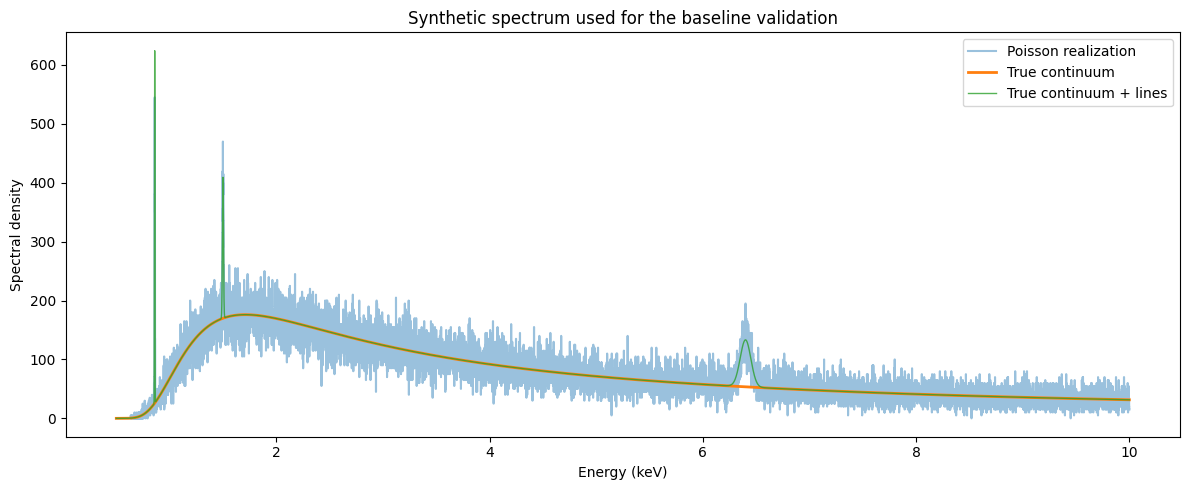

In [4]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    energy,
    values,
    drawstyle="steps-mid",
    alpha=0.45,
    label="Poisson realization",
)
ax.plot(
    energy,
    continuum,
    linewidth=2,
    label="True continuum",
)
ax.plot(
    energy,
    model,
    linewidth=1,
    alpha=0.8,
    label="True continuum + lines",
)

ax.set_xlabel("Energy (keV)")
ax.set_ylabel("Spectral density")
ax.set_title("Synthetic spectrum used for the baseline validation")
ax.legend()
fig.tight_layout()

if SAVE_FIGURES:
    fig.savefig(OUTPUT_DIR / "synthetic_spectrum.pdf", bbox_inches="tight")

plt.show()


## 3. Visual stability against rebinning

Before running the Monte Carlo experiment, we inspect one realization at several target bin widths while keeping the baseline window fixed at the current reference value of **0.4 keV**.

This is only a visual sanity check. The quantitative test below uses many independent Poisson realizations and compares the recovered line area with the **true line model after exactly the same rebinning**.

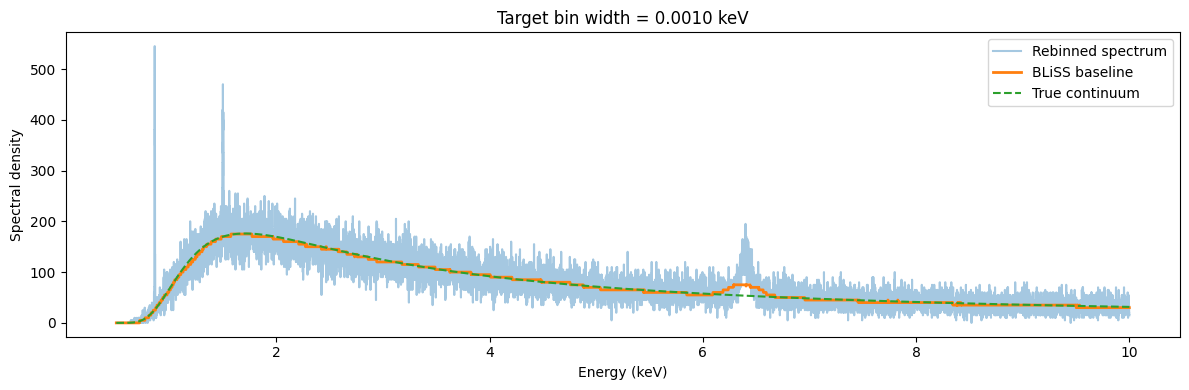

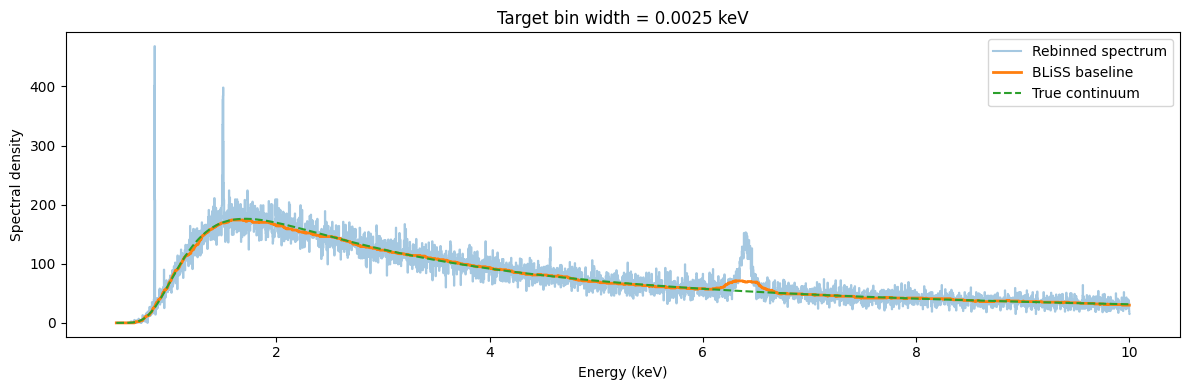

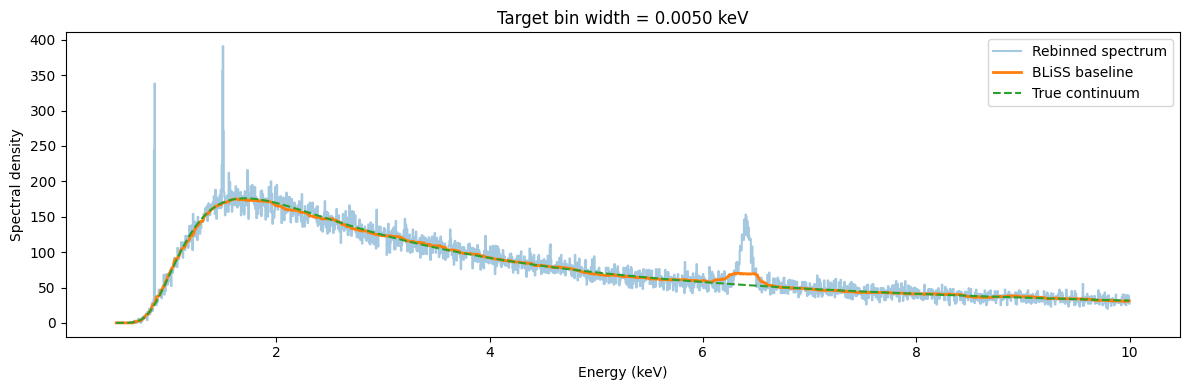

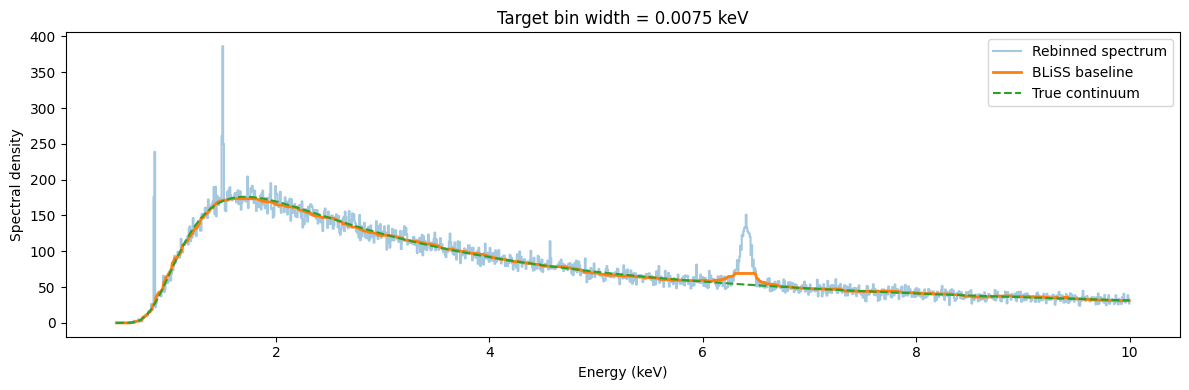

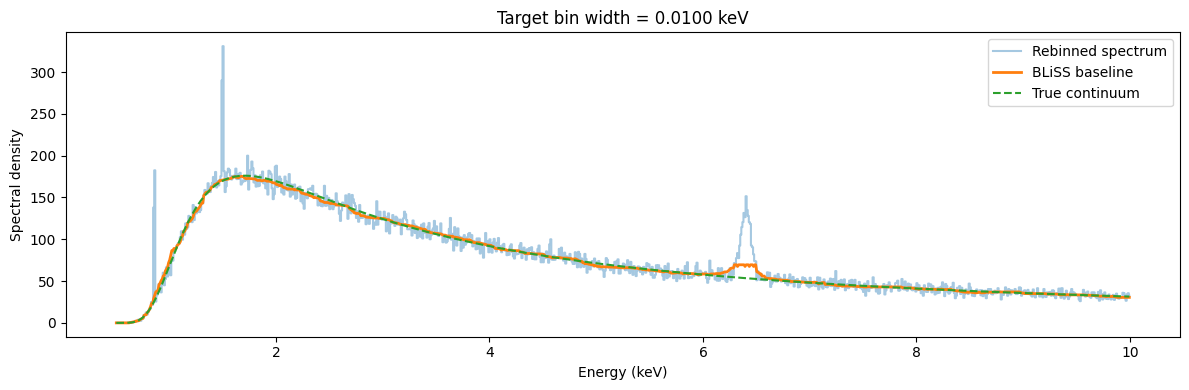

In [5]:
rebin_resolutions = [0.001, 0.0025, 0.005, 0.0075, 0.010]
reference_baseline_window = 0.4

for resolution in rebin_resolutions:
    e_reb, y_reb, sy_reb = rebin_resolution(
        energy,
        values,
        errors,
        resolution,
    )

    baseline_reb = base_calculator(
        e_reb,
        y_reb,
        baseline_window=reference_baseline_window,
    )

    true_cont_reb = np.interp(e_reb, energy, continuum)

    fig, ax = plt.subplots(figsize=(12, 4))

    ax.plot(
        e_reb,
        y_reb,
        drawstyle="steps-mid",
        alpha=0.4,
        label="Rebinned spectrum",
    )
    ax.plot(
        e_reb,
        baseline_reb,
        linewidth=2,
        label="BLiSS baseline",
    )
    ax.plot(
        e_reb,
        true_cont_reb,
        linestyle="--",
        linewidth=1.5,
        label="True continuum",
    )

    ax.set_title(f"Target bin width = {resolution:.4f} keV")
    ax.set_xlabel("Energy (keV)")
    ax.set_ylabel("Spectral density")
    ax.legend()
    fig.tight_layout()

    if SAVE_FIGURES:
        fig.savefig(
            OUTPUT_DIR / f"baseline_rebin_{resolution:.4f}.pdf",
            bbox_inches="tight",
        )

    plt.show()


## 4. Monte Carlo sensitivity experiment

We now vary two quantities independently:

- **target rebinning scale:** 0.001--0.010 keV;
- **running-median baseline window:** 0.1--0.5 keV.

For each combination we generate **50 independent Poisson realizations**.

Two diagnostics are measured.

### 4.1 Line-area recovery

For each injected line, the residual spectrum is integrated within $\pm 3\sigma$ of the known line centroid.

Importantly, the denominator is **not** the analytic input area. Instead, the true injected line model is passed through exactly the same `rebin_resolution` operation and integrated on the same rebinned grid. This separates flux lost through sampling/rebinning from flux absorbed by the baseline estimator itself.

A recovered fraction close to 1 therefore indicates that the baseline preserves the line area available at that sampling scale.

### 4.2 Continuum bias

Outside $\pm 3\sigma$ around all injected lines, the baseline is compared directly with the known rebinned continuum. We record:

- the median fractional bias, which reveals a systematic high/low offset;
- the median absolute fractional error, which measures the typical baseline discrepancy independently of its sign.

This directly tests whether the empirical baseline is systematically biased below the known continuum.

In [6]:
rebin_resolutions = [
    0.001,
    0.0025,
    0.005,
    0.0075,
    0.010,
]

baseline_windows = [
    0.1,
    0.2,
    0.3,
    0.4,
    0.5,
]

n_simulations = 50
max_range_fraction = 0.2

results = []

for simulation in range(n_simulations):
    rng = np.random.default_rng(simulation)

    # --------------------------------------------------
    # Independent Poisson realization
    # --------------------------------------------------
    expected_counts = model * dE * exposure
    counts = rng.poisson(expected_counts)

    values_sim = counts / (dE * exposure)
    errors_sim = np.sqrt(np.maximum(counts, 1)) / (dE * exposure)

    # --------------------------------------------------
    # Rebin the noisy spectrum and the known components
    # --------------------------------------------------
    for resolution in rebin_resolutions:
        e_reb, y_reb, sy_reb = rebin_resolution(
            energy,
            values_sim,
            errors_sim,
            resolution,
        )

        # Rebin the TRUE line model using the same operation.
        _, true_line_reb, _ = rebin_resolution(
            energy,
            line_model,
            errors_sim,
            resolution,
        )

        # Rebin the TRUE continuum using the same operation.
        _, true_continuum_reb, _ = rebin_resolution(
            energy,
            continuum,
            errors_sim,
            resolution,
        )

        # --------------------------------------------------
        # Baseline-window sensitivity
        # --------------------------------------------------
        for baseline_window in baseline_windows:
            baseline_reb, info = base_calculator(
                e_reb,
                y_reb,
                baseline_window=baseline_window,
                max_range_fraction=max_range_fraction,
                return_info=True,
            )

            residual_reb = y_reb - baseline_reb

            # ----------------------------------------------
            # Continuum accuracy outside injected lines
            # ----------------------------------------------
            continuum_mask = np.ones(len(e_reb), dtype=bool)

            for line in lines:
                continuum_mask &= ~(
                    (e_reb >= line["center"] - 3.0 * line["sigma"])
                    & (e_reb <= line["center"] + 3.0 * line["sigma"])
                )

            good_continuum = (
                continuum_mask
                & np.isfinite(baseline_reb)
                & np.isfinite(true_continuum_reb)
                & (true_continuum_reb != 0)
            )

            if np.any(good_continuum):
                continuum_fractional_error = (
                    baseline_reb[good_continuum]
                    - true_continuum_reb[good_continuum]
                ) / true_continuum_reb[good_continuum]

                continuum_bias = np.median(continuum_fractional_error)
                continuum_absolute_error = np.median(
                    np.abs(continuum_fractional_error)
                )
            else:
                continuum_bias = np.nan
                continuum_absolute_error = np.nan

            # ----------------------------------------------
            # Recovery of each injected line
            # ----------------------------------------------
            for line in lines:
                center = line["center"]
                sigma = line["sigma"]

                mask_line = (
                    (e_reb >= center - 3.0 * sigma)
                    & (e_reb <= center + 3.0 * sigma)
                )

                n_bins_line = int(mask_line.sum())

                if n_bins_line >= 2:
                    expected_area_rebinned = np.trapezoid(
                        true_line_reb[mask_line],
                        e_reb[mask_line],
                    )

                    recovered_area = np.trapezoid(
                        residual_reb[mask_line],
                        e_reb[mask_line],
                    )

                    if expected_area_rebinned > 0:
                        recovered_fraction = (
                            recovered_area / expected_area_rebinned
                        )
                    else:
                        recovered_fraction = np.nan
                else:
                    expected_area_rebinned = np.nan
                    recovered_area = np.nan
                    recovered_fraction = np.nan

                results.append(
                    {
                        "simulation": simulation,
                        "rebin_resolution": resolution,
                        "baseline_window_requested": baseline_window,
                        "baseline_window_used": np.nanmedian(
                            info["window_width"]
                        ),
                        "line_center": center,
                        "line_sigma": sigma,
                        "n_bins_line": n_bins_line,
                        "expected_area_rebinned": expected_area_rebinned,
                        "recovered_area": recovered_area,
                        "recovered_fraction": recovered_fraction,
                        "continuum_bias": continuum_bias,
                        "continuum_absolute_error": continuum_absolute_error,
                    }
                )

results_pd = pd.DataFrame(results)

results_pd.to_csv(
    OUTPUT_DIR / "baseline_recovery_all_realizations.csv",
    index=False,
)

results_pd.head()


,simulation,rebin_resolution,baseline_window_requested,baseline_window_used,line_center,line_sigma,n_bins_line,expected_area_rebinned,recovered_area,recovered_fraction,continuum_bias,continuum_absolute_error
0,0,0.001,0.1,0.1,0.86,0.002,12,2.973810,3.10750,1.044956,-0.012228,0.029381
1,0,0.001,0.1,0.1,1.50,0.005,30,2.987932,2.69625,0.902380,-0.012228,0.029381
2,0,0.001,0.1,0.1,6.40,0.050,300,9.972079,0.24000,0.024067,-0.012228,0.029381
3,0,0.001,0.2,0.2,0.86,0.002,12,2.973810,3.11000,1.045797,-0.009321,0.025713
4,0,0.001,0.2,0.2,1.50,0.005,30,2.987932,2.82000,0.943797,-0.009321,0.025713


## 5. Aggregate the Monte Carlo results

For every line width, rebinning scale, and baseline window, we summarize the 50 realizations using the median recovered fraction and its realization-to-realization standard deviation.

The continuum diagnostics are independent of which line row is being stored, so they are summarized separately after removing the repeated line entries.

In [7]:
summary_pd = (
    results_pd
    .groupby(
        [
            "line_sigma",
            "rebin_resolution",
            "baseline_window_requested",
        ]
    )
    .agg(
        recovery_median=("recovered_fraction", "median"),
        recovery_std=("recovered_fraction", "std"),
        median_bins_in_3sigma=("n_bins_line", "median"),
        baseline_window_used=("baseline_window_used", "median"),
    )
    .reset_index()
)

summary_pd["recovery_percent"] = 100.0 * summary_pd["recovery_median"]
summary_pd["recovery_std_percent"] = 100.0 * summary_pd["recovery_std"]

# Continuum metrics are repeated once per injected line in results_pd.
continuum_realizations = results_pd.drop_duplicates(
    subset=[
        "simulation",
        "rebin_resolution",
        "baseline_window_requested",
    ]
)

continuum_summary = (
    continuum_realizations
    .groupby(
        [
            "rebin_resolution",
            "baseline_window_requested",
        ]
    )
    .agg(
        continuum_bias_median=("continuum_bias", "median"),
        continuum_bias_std=("continuum_bias", "std"),
        continuum_absolute_error_median=(
            "continuum_absolute_error",
            "median",
        ),
        baseline_window_used=("baseline_window_used", "median"),
    )
    .reset_index()
)

continuum_summary["continuum_bias_percent"] = (
    100.0 * continuum_summary["continuum_bias_median"]
)
continuum_summary["continuum_error_percent"] = (
    100.0 * continuum_summary["continuum_absolute_error_median"]
)

summary_pd.to_csv(
    OUTPUT_DIR / "baseline_line_recovery_summary.csv",
    index=False,
)

continuum_summary.to_csv(
    OUTPUT_DIR / "baseline_continuum_summary.csv",
    index=False,
)

summary_pd.head()


,line_sigma,rebin_resolution,baseline_window_requested,recovery_median,recovery_std,median_bins_in_3sigma,baseline_window_used,recovery_percent,recovery_std_percent
0,0.002,0.001,0.1,0.999560,0.048186,12.0,0.1,99.955955,4.818585
1,0.002,0.001,0.2,1.003343,0.046906,12.0,0.2,100.334257,4.690579
2,0.002,0.001,0.3,1.003763,0.046857,12.0,0.3,100.376291,4.685675
3,0.002,0.001,0.4,1.004393,0.046755,12.0,0.4,100.439341,4.675511
4,0.002,0.001,0.5,1.003763,0.046809,12.0,0.5,100.376291,4.680852


## 6. Line-recovery heatmaps

Each panel below corresponds to one injected line width.

- **x-axis:** target rebinning scale;
- **y-axis:** requested baseline window;
- **cell value/color:** median recovered line area over the 50 Poisson realizations.

The same color scale is used for all lines. Values close to 100% indicate that the baseline preserves the line flux available on the rebinned grid. Broad lines are expected to be more sensitive to small baseline windows because their characteristic scale begins to overlap with the scale used to define the broad spectral shape.

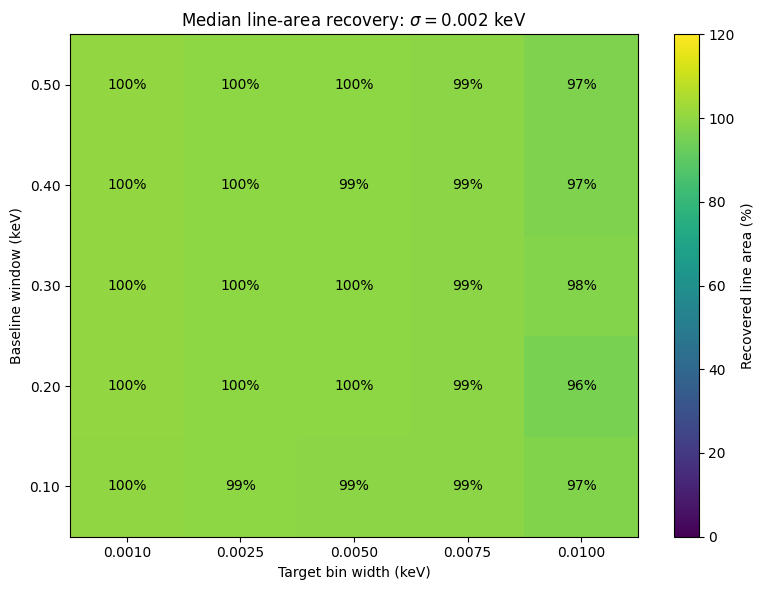

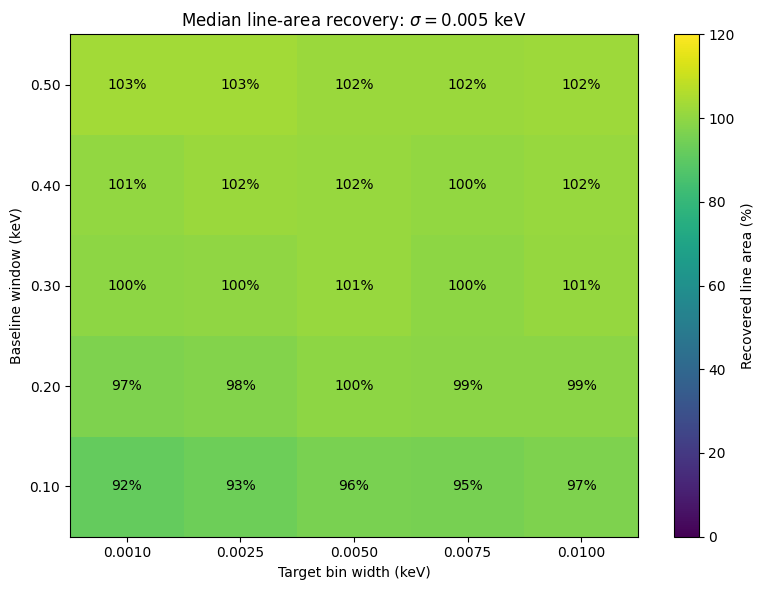

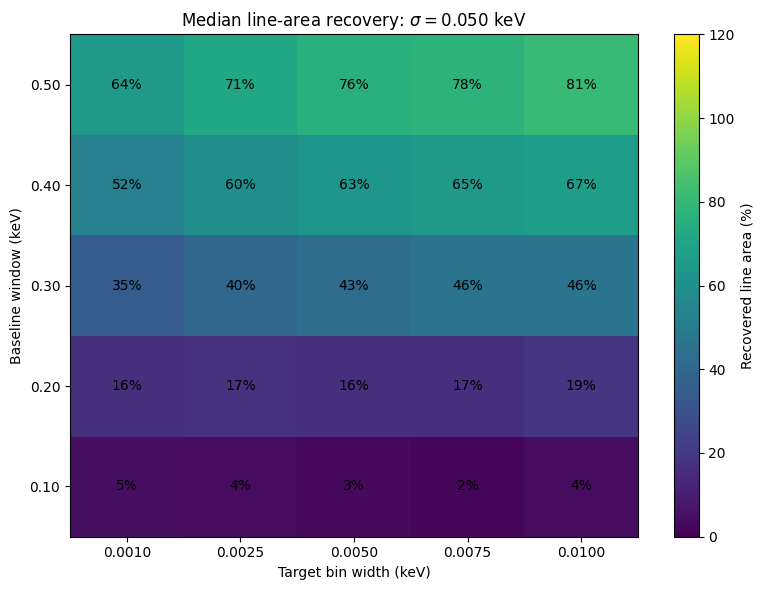

In [8]:
for line_sigma in sorted(summary_pd["line_sigma"].unique()):
    subset = summary_pd[
        summary_pd["line_sigma"] == line_sigma
    ]

    heatmap = subset.pivot(
        index="baseline_window_requested",
        columns="rebin_resolution",
        values="recovery_percent",
    )

    fig, ax = plt.subplots(figsize=(8, 6))

    im = ax.imshow(
        heatmap.values,
        origin="lower",
        aspect="auto",
        vmin=0,
        vmax=120,
    )

    ax.set_xticks(np.arange(len(heatmap.columns)))
    ax.set_xticklabels(
        [f"{value:.4f}" for value in heatmap.columns]
    )

    ax.set_yticks(np.arange(len(heatmap.index)))
    ax.set_yticklabels(
        [f"{value:.2f}" for value in heatmap.index]
    )

    ax.set_xlabel("Target bin width (keV)")
    ax.set_ylabel("Baseline window (keV)")
    ax.set_title(
        rf"Median line-area recovery: $\sigma={line_sigma:.3f}$ keV"
    )

    for i in range(len(heatmap.index)):
        for j in range(len(heatmap.columns)):
            value = heatmap.iloc[i, j]
            if np.isfinite(value):
                ax.text(
                    j,
                    i,
                    f"{value:.0f}%",
                    ha="center",
                    va="center",
                )

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("Recovered line area (%)")

    fig.tight_layout()

    if SAVE_FIGURES:
        fig.savefig(
            OUTPUT_DIR / f"line_recovery_sigma_{line_sigma:.3f}.pdf",
            bbox_inches="tight",
        )

    plt.show()


## 7. Continuum-bias diagnostic

The following heatmap tests a separate question: **does the running-median estimator systematically sit above or below the known continuum?**

The value shown is the median fractional baseline bias outside all injected line regions, averaged over 50 Poisson realizations. A value close to zero is desirable. Negative values indicate a baseline below the true continuum; positive values indicate an overestimate.

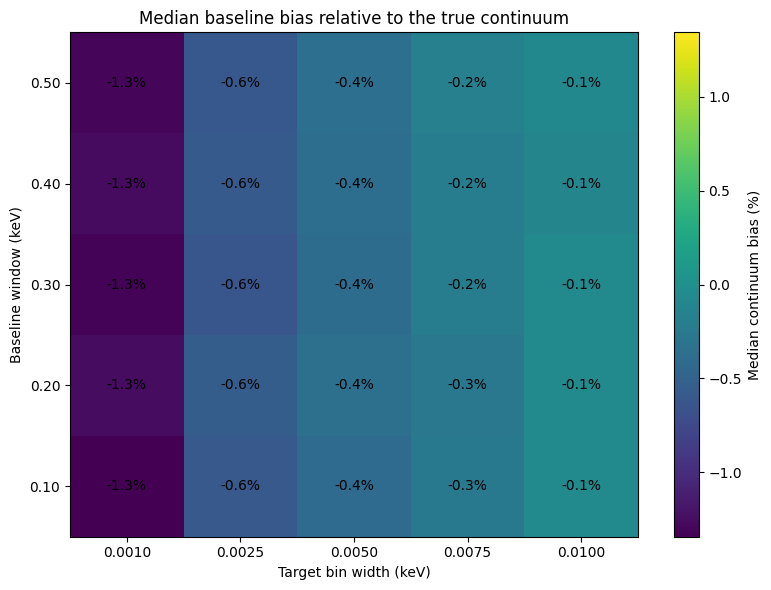

In [9]:
bias_heatmap = continuum_summary.pivot(
    index="baseline_window_requested",
    columns="rebin_resolution",
    values="continuum_bias_percent",
)

fig, ax = plt.subplots(figsize=(8, 6))

max_abs_bias = np.nanmax(np.abs(bias_heatmap.values))
if not np.isfinite(max_abs_bias) or max_abs_bias == 0:
    max_abs_bias = 1.0

im = ax.imshow(
    bias_heatmap.values,
    origin="lower",
    aspect="auto",
    vmin=-max_abs_bias,
    vmax=max_abs_bias,
)

ax.set_xticks(np.arange(len(bias_heatmap.columns)))
ax.set_xticklabels(
    [f"{value:.4f}" for value in bias_heatmap.columns]
)

ax.set_yticks(np.arange(len(bias_heatmap.index)))
ax.set_yticklabels(
    [f"{value:.2f}" for value in bias_heatmap.index]
)

ax.set_xlabel("Target bin width (keV)")
ax.set_ylabel("Baseline window (keV)")
ax.set_title("Median baseline bias relative to the true continuum")

for i in range(len(bias_heatmap.index)):
    for j in range(len(bias_heatmap.columns)):
        value = bias_heatmap.iloc[i, j]
        if np.isfinite(value):
            ax.text(
                j,
                i,
                f"{value:+.1f}%",
                ha="center",
                va="center",
            )

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Median continuum bias (%)")

fig.tight_layout()

if SAVE_FIGURES:
    fig.savefig(
        OUTPUT_DIR / "continuum_bias_heatmap.pdf",
        bbox_inches="tight",
    )

plt.show()


### Typical continuum error

Bias alone can cancel positive and negative deviations. We therefore also inspect the median absolute fractional error of the empirical baseline with respect to the known continuum.

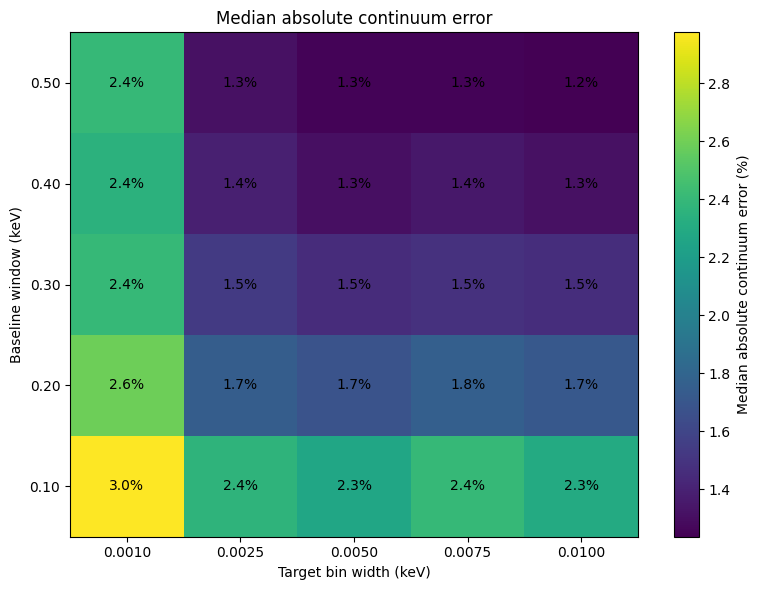

In [10]:
error_heatmap = continuum_summary.pivot(
    index="baseline_window_requested",
    columns="rebin_resolution",
    values="continuum_error_percent",
)

fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(
    error_heatmap.values,
    origin="lower",
    aspect="auto",
)

ax.set_xticks(np.arange(len(error_heatmap.columns)))
ax.set_xticklabels(
    [f"{value:.4f}" for value in error_heatmap.columns]
)

ax.set_yticks(np.arange(len(error_heatmap.index)))
ax.set_yticklabels(
    [f"{value:.2f}" for value in error_heatmap.index]
)

ax.set_xlabel("Target bin width (keV)")
ax.set_ylabel("Baseline window (keV)")
ax.set_title("Median absolute continuum error")

for i in range(len(error_heatmap.index)):
    for j in range(len(error_heatmap.columns)):
        value = error_heatmap.iloc[i, j]
        if np.isfinite(value):
            ax.text(
                j,
                i,
                f"{value:.1f}%",
                ha="center",
                va="center",
            )

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Median absolute continuum error (%)")

fig.tight_layout()

if SAVE_FIGURES:
    fig.savefig(
        OUTPUT_DIR / "continuum_absolute_error_heatmap.pdf",
        bbox_inches="tight",
    )

plt.show()


## 8. Reference configuration: 0.4 keV baseline window

This compact table isolates the current reference baseline scale. It is useful for reporting the recovery as a function of line width and rebinning without averaging over the sampling conditions.

When interpreting the narrowest injected line, the number of bins contained inside $\pm 3\sigma$ should also be inspected: once a line is represented by only a few bins, sampling rather than baseline estimation can dominate its recoverability.

In [11]:
reference_window = 0.4

reference_recovery = (
    summary_pd[
        summary_pd["baseline_window_requested"] == reference_window
    ]
    [
        [
            "line_sigma",
            "rebin_resolution",
            "median_bins_in_3sigma",
            "recovery_percent",
            "recovery_std_percent",
        ]
    ]
    .sort_values(
        ["line_sigma", "rebin_resolution"]
    )
    .reset_index(drop=True)
)

reference_recovery


,line_sigma,rebin_resolution,median_bins_in_3sigma,recovery_percent,recovery_std_percent
0,0.002,0.0010,12.0,100.439341,4.675511
1,0.002,0.0025,5.0,99.525465,4.931607
2,0.002,0.0050,2.0,99.455940,4.754258
3,0.002,0.0075,2.0,99.074969,4.731929
4,0.002,0.0100,2.0,96.791750,4.889081
5,0.005,0.0010,30.0,100.696750,6.972145
6,0.005,0.0025,12.0,102.170640,6.631650
7,0.005,0.0050,6.0,101.614960,6.468402
8,0.005,0.0075,4.0,100.498650,6.654107
9,0.005,0.0100,3.0,101.709859,6.889067


In [12]:
reference_continuum = (
    continuum_summary[
        continuum_summary["baseline_window_requested"] == reference_window
    ]
    [
        [
            "rebin_resolution",
            "continuum_bias_percent",
            "continuum_error_percent",
        ]
    ]
    .sort_values("rebin_resolution")
    .reset_index(drop=True)
)

reference_continuum


,rebin_resolution,continuum_bias_percent,continuum_error_percent
0,0.0010,-1.263215,2.350371
1,0.0025,-0.580372,1.390857
2,0.0050,-0.376811,1.305994
3,0.0075,-0.207058,1.350686
4,0.0100,-0.121946,1.316825


## 9. How to interpret this validation

This experiment is designed to establish **robustness**, not to identify a uniquely optimal baseline window.

A useful default should satisfy three conditions simultaneously:

1. **narrow-line preservation:** recovered fractions remain close to unity for well-sampled narrow lines;
2. **parameter stability:** comparable results are obtained over a reasonably broad range of neighboring baseline windows rather than at one finely tuned value;
3. **continuum fidelity:** the empirical baseline has a small absolute error and no substantial systematic negative bias relative to the known continuum.

The deliberately broad $\sigma=0.05$ keV line is included as a stress test. A running-median window approaching the characteristic width of such a broad feature can absorb part of that feature into the baseline. This behavior is expected and illustrates why the baseline window remains user-configurable. In soft-X-ray or restricted-energy analyses, where the relevant spectral structures occur on smaller energy scales, BLiSS can also accept a smaller or energy-dependent baseline window.

### Scope of this notebook

This notebook validates only the empirical-baseline stage. It does **not** calibrate the downstream BLiSS reliability score, false-positive rate, or completeness of the full line-detection pipeline; those require separate injection-recovery tests of the complete workflow.